In [1]:
# =============================================================================
# 12d — Statistics and figures
#
# GEOMETRY must match 12a, 12b, 12c.
# Run once per pooling.
#
# Pre-registered confirmatory tests
#   E1  alpha=0 versus alpha=5, attention-CAM, MEL union, paired by image
#   E2  finercam versus gradcam_a, activation alpha=5, MEL images only
# Everything else is exploratory and labelled as such.
#
# Deliverables for the manuscript
#   Table 1  main, alpha 0 versus 5, mean +/- std
#   Table 2  ablation, all alpha, both poolings, both formulations
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu
from PIL import Image
import cv2


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.eval.cam_eval_utils import (
    transform_mask, transform_rgb, cam_to_grid, norm01,
    CAM_GRID, CROP_SIZE)

# ---- switches, must match 12a, 12b, 12c -----------------------------------
GEOMETRY = "squash224"
POOLING  = "cls"                 # "mean" for GAP, "cls" for CLS
POOL_TAG = "gap" if POOLING == "mean" else "cls"

HAM_ROOT  = REPO / "data" / "HAM10000"
EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
RES       = REPO / "results" / "overlap" / POOL_TAG / GEOMETRY
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
FIG       = RES / "figures"
FIG.mkdir(parents=True, exist_ok=True)

for p in [RES / "overlap_metrics_long.csv", RES / "lesion_conditioned_metrics.csv",
          RES / "observed_vs_null.csv", EVAL_ROOT / "predictions.csv", QC_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f"missing {p}. Run 12c with GEOMETRY={GEOMETRY} POOLING={POOLING}.")

long_df = pd.read_csv(RES / "overlap_metrics_long.csv")
cond_df = pd.read_csv(RES / "lesion_conditioned_metrics.csv")
nullcmp = pd.read_csv(RES / "observed_vs_null.csv")
pred    = pd.read_csv(EVAL_ROOT / "predictions.csv")
eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
man     = pd.read_csv(EVAL_ROOT / "cam_manifest.csv")
qcp     = pd.read_csv(QC_CSV).query("qc_pass")

TOP_K  = 20
N_BOOT = 10000


def alpha_value(ck):
    """ha0 -> 0.0, ha0p25 -> 0.25, ha17 -> 17.0"""
    return float(str(ck).replace("ha", "").replace("p", "."))


ALPHAS = sorted(man.ckpt.unique(), key=alpha_value)
AVAL   = {c: alpha_value(c) for c in ALPHAS}

METRICS_RAW = [("cam_auc", "AUC"), ("dice", "Dice"),
               ("dice_norm", "Dice / ceiling"),
               ("iou", "IoU"), ("pointing", "Pointing game")]
METRICS_RAW = [(m, n) for m, n in METRICS_RAW if m in long_df.columns]

C_ATTN, C_ACT = "#1F77B4", "#7F3F98"
C_MEL,  C_NV  = "#C62828", "#2E7D32"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

mel_n = long_df.query('target == "union_MEL"').image_id.nunique()
print(f"geometry {GEOMETRY}   pooling {POOL_TAG}")
print(f"long {len(long_df)}  cond {len(cond_df)}  images {eval_df.image_id.nunique()}")
print(f"MEL union images {mel_n}")
print(f"alphas found: {[f'{c}={AVAL[c]:g}' for c in ALPHAS]}")
print(f"metrics available: {[n for _, n in METRICS_RAW]}")

missing = [m for m in ["dice", "dice_norm", "iou", "pointing"]
           if m not in long_df.columns]
if missing:
    print(f"\nMISSING {missing}. Patch overlap_metrics in 12c and rerun.")

geometry squash224   pooling cls
long 3190  cond 990  images 34
MEL union images 31
alphas found: ['ha0=0', 'ha3=3', 'ha5=5']
metrics available: ['AUC', 'Dice', 'Dice / ceiling', 'IoU', 'Pointing game']


In [2]:
# =============================================================================
# Wilcoxon signed rank with a bootstrap CI on the median paired difference.
# With n around 30 the CI is more informative than the p value. Report both.
# rank_biserial ranges -1 to 1. Positive means source A scores higher.
# =============================================================================
def paired_stats(df, metric, key_col, a, b, n_boot=N_BOOT, seed=0):
    p = (df.pivot_table(index="image_id", columns=key_col, values=metric)
           .reindex(columns=[a, b]).dropna())
    if len(p) < 5:
        return {"n": len(p), "note": "too few pairs"}

    d = (p[a] - p[b]).to_numpy()
    nz = d[d != 0]

    if len(nz) == 0:
        stat, pval, rb = np.nan, 1.0, 0.0
    else:
        stat, pval = wilcoxon(p[a], p[b])
        ranks = pd.Series(np.abs(nz)).rank().to_numpy()
        wp, wm = ranks[nz > 0].sum(), ranks[nz < 0].sum()
        rb = (wp - wm) / (wp + wm)

    rng = np.random.default_rng(seed)
    boot = np.array([np.median(rng.choice(d, len(d), replace=True))
                     for _ in range(n_boot)])

    return {
        "n": len(p),
        f"median_{a}": float(np.median(p[a])),
        f"median_{b}": float(np.median(p[b])),
        f"mean_{a}": float(np.mean(p[a])), f"std_{a}": float(np.std(p[a], ddof=1)),
        f"mean_{b}": float(np.mean(p[b])), f"std_{b}": float(np.std(p[b], ddof=1)),
        "median_diff": float(np.median(d)),
        "ci_lo": float(np.percentile(boot, 2.5)),
        "ci_hi": float(np.percentile(boot, 97.5)),
        "p": float(pval),
        "rank_biserial": float(rb),
        "n_favour_a": int((d > 0).sum()),
        "n_favour_b": int((d < 0).sum()),
    }


def boot_median_ci(x, n_boot=N_BOOT, seed=0):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    b = np.array([np.median(rng.choice(x, len(x), replace=True))
                  for _ in range(n_boot)])
    return float(np.median(x)), float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))


def mean_std(x, dp=3):
    """Supervisor convention for the manuscript tables."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return "-"
    return f"{np.mean(x):.{dp}f} $\\pm$ {np.std(x, ddof=1):.{dp}f}"


def fmt(r):
    if "note" in r:
        return r["note"]
    return (f"n={r['n']}  diff={r['median_diff']:+.3f} "
            f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  "
            f"p={r['p']:.4f}  r={r['rank_biserial']:+.2f}  "
            f"({r['n_favour_a']}/{r['n_favour_b']})")

In [3]:
# =============================================================================
# E1. Does alignment training improve overlap with clinician features.
#
# Now reports AUC, Dice, IoU and pointing game, not AUC alone.
# Dice and pointing game were requested explicitly.
# =============================================================================
mel_raw = long_df.query("target == 'union_MEL'")
mel_con = cond_df.query("target == 'union_MEL'")

A_LO = "ha0"
A_HI = "ha5" if "ha5" in ALPHAS else ALPHAS[-1]

rows = []
for fam, ct_map, fname in [("attn", "attncam_a", "attention"),
                           ("act",  "gradcam_a", "activation")]:
    sub = mel_raw[(mel_raw.family == fam) & (mel_raw.cam_type == ct_map)]
    for metric, mname in METRICS_RAW:
        for a, b in [(A_HI, A_LO)] + \
                    ([("ha3", A_LO), (A_HI, "ha3")] if "ha3" in ALPHAS else []):
            if a not in sub.ckpt.values or b not in sub.ckpt.values:
                continue
            r = paired_stats(sub, metric, "ckpt", a, b)
            rows.append({"formulation": fname, "scope": "raw",
                         "metric": mname, "contrast": f"{a} vs {b}", **r})

    subc = mel_con[(mel_con.family == fam) & (mel_con.cam_type == ct_map)]
    for a, b in [(A_HI, A_LO)]:
        if a in subc.ckpt.values and b in subc.ckpt.values:
            r = paired_stats(subc, "c_auc", "ckpt", a, b)
            rows.append({"formulation": fname, "scope": "in-lesion",
                         "metric": "AUC", "contrast": f"{a} vs {b}", **r})

e1 = pd.DataFrame(rows)
e1["pooling"] = POOL_TAG
e1.to_csv(RES / "E1_statistics.csv", index=False)

for fam in e1.formulation.unique():
    for sc in e1[e1.formulation == fam].scope.unique():
        print(f"\n{fam}, {sc}")
        for _, r in e1[(e1.formulation == fam) & (e1.scope == sc)].iterrows():
            print(f"  {r.metric:<14} {r.contrast:<12} {fmt(r)}")

target_contrast = f"{A_HI} vs {A_LO}"

pr = e1[(e1.formulation == "attention") &
        (e1.scope == "raw") &
        (e1.metric == "AUC") &
        (e1.contrast == target_contrast)]

if len(pr):
    pr = pr.iloc[0]
    print(f"\n\nPRIMARY TEST, attention raw AUC, {A_HI} versus {A_LO}")
    print(f"  {pr[f'median_{A_LO}']:.3f} -> {pr[f'median_{A_HI}']:.3f}")
    print(f"  diff {pr.median_diff:+.3f}  95% CI [{pr.ci_lo:+.3f}, {pr.ci_hi:+.3f}]")
    print(f"  p {pr.p:.2e}   favours {A_HI} in {pr.n_favour_a} of {pr.n}")
else:
    print(f"\n\nprimary contrast '{target_contrast}' not found")
    print("available:", sorted(e1.contrast.unique()))


attention, raw
  AUC            ha5 vs ha0   n=31  diff=+0.383 [+0.312, +0.433]  p=0.0000  r=+1.00  (31/0)
  AUC            ha3 vs ha0   n=31  diff=+0.387 [+0.316, +0.433]  p=0.0000  r=+1.00  (31/0)
  AUC            ha5 vs ha3   n=31  diff=+0.001 [+0.000, +0.001]  p=0.1631  r=+0.30  (20/9)
  Dice           ha5 vs ha0   n=31  diff=+0.235 [+0.143, +0.302]  p=0.0000  r=+1.00  (30/0)
  Dice           ha3 vs ha0   n=31  diff=+0.229 [+0.163, +0.301]  p=0.0000  r=+1.00  (30/0)
  Dice           ha5 vs ha3   n=31  diff=+0.000 [+0.000, +0.000]  p=0.5073  r=+0.24  (6/4)
  Dice / ceiling ha5 vs ha0   n=31  diff=+0.300 [+0.250, +0.500]  p=0.0000  r=+1.00  (30/0)
  Dice / ceiling ha3 vs ha0   n=31  diff=+0.389 [+0.250, +0.500]  p=0.0000  r=+1.00  (30/0)
  Dice / ceiling ha5 vs ha3   n=31  diff=+0.000 [+0.000, +0.000]  p=0.5073  r=+0.24  (6/4)
  IoU            ha5 vs ha0   n=31  diff=+0.193 [+0.127, +0.237]  p=0.0000  r=+1.00  (30/0)
  IoU            ha3 vs ha0   n=31  diff=+0.193 [+0.114, +0.236]  

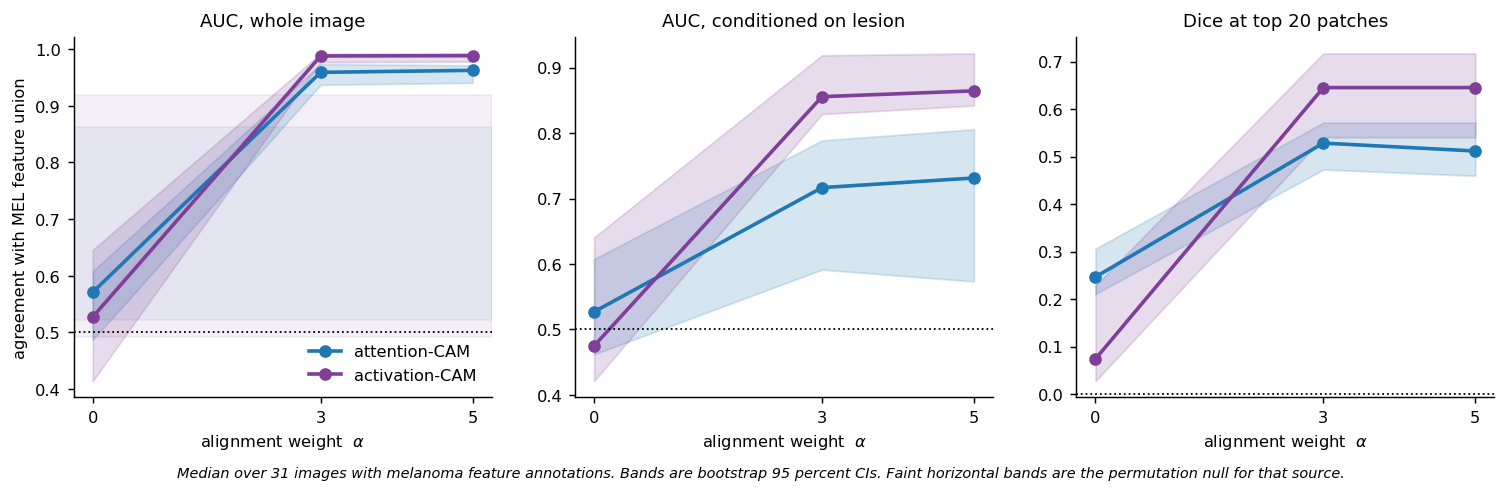

In [4]:
# =============================================================================
# FIGURE 1. Dose response across three views.
#
# EXPECT steep rise 0 to 3, flat after. Raw above in-lesion.
# READ   the gap between a curve and its own null band is the real effect.
#        Activation has the higher raw AUC and the smaller gap.
# =============================================================================
panels = [("cam_auc", mel_raw, "AUC, whole image"),
          ("c_auc",   mel_con, "AUC, conditioned on lesion")]
if "dice" in long_df.columns:
    panels.append(("dice", mel_raw, f"Dice at top {TOP_K} patches"))

fig, axes = plt.subplots(1, len(panels), figsize=(4.7 * len(panels), 3.6))
axes = np.atleast_1d(axes)

for ax, (metric, df, title) in zip(axes, panels):
    for fam, ct, col, name in [("attn", "attncam_a", C_ATTN, "attention-CAM"),
                               ("act",  "gradcam_a", C_ACT,  "activation-CAM")]:
        sub = df[(df.family == fam) & (df.cam_type == ct)]
        xs, ys, lo, hi = [], [], [], []
        for ck in ALPHAS:
            v = sub[sub.ckpt == ck][metric]
            if not len(v):
                continue
            m, l, h = boot_median_ci(v)
            xs.append(AVAL[ck]); ys.append(m); lo.append(l); hi.append(h)
        if xs:
            ax.plot(xs, ys, "o-", color=col, label=name, lw=2, ms=6)
            ax.fill_between(xs, lo, hi, color=col, alpha=0.18)

        # null band, this specific source only
        if metric == "cam_auc":
            nv = nullcmp[(nullcmp.target == "union_MEL") &
                         nullcmp.source.isin([f"{fam}_{c}_{ct}" for c in ALPHAS])]
            if len(nv):
                ax.axhspan(nv.null_auc_mean.min(), nv.null_auc_mean.max(),
                           color=col, alpha=0.08)

    ax.axhline(0.5 if "auc" in metric else 0, color="k", ls=":", lw=1)
    xs_all = sorted(AVAL[c] for c in ALPHAS)
    ax.set_xticks(xs_all if len(xs_all) <= 6 else xs_all[::2])
    ax.set_xlabel(r"alignment weight  $\alpha$")
    ax.set_title(title)

axes[0].set_ylabel("agreement with MEL feature union")
axes[0].legend(frameon=False, loc="lower right")
fig.text(0.5, -0.06,
         f"Median over {mel_n} images with melanoma feature annotations. "
         f"Bands are bootstrap 95 percent CIs. Faint horizontal bands are the "
         f"permutation null for that source.",
         ha="center", fontsize=8, style="italic")
fig.savefig(FIG / "fig1_E1_dose_response.png")
plt.show()

In [5]:
# =============================================================================
# E2. Does Finer-CAM outperform Grad-CAM on melanoma specific features.
# MEL class images only. n is small so effect size leads, p follows.
# =============================================================================
CK5 = A_HI
e2src = long_df[(long_df.target == "union_MEL") &
                (long_df.family == "act") &
                (long_df.ckpt == CK5) &
                (long_df.gt_label == "MEL")].copy()

e2src["variant"] = np.where(
    e2src.cam_type == "finercam",
    "finercam_g" + e2src.gamma.astype(str).str.replace(".", "p", regex=False),
    e2src.cam_type)

print("variants:", sorted(e2src.variant.unique()))
print(f"MEL images: {e2src.image_id.nunique()}\n")

CONTRASTS = [("finercam_g0p6", "gradcam_a"),
             ("finercam_g0p8", "gradcam_a"),
             ("finercam_g0p6", "finercam_g0p8"),
             ("map_diff",      "gradcam_a"),
             ("gradcam_a",     "gradcam_b")]

rows = []
for metric, mname in METRICS_RAW:
    for a, b in CONTRASTS:
        if a not in e2src.variant.values or b not in e2src.variant.values:
            continue
        r = paired_stats(e2src, metric, "variant", a, b)
        rows.append({"metric": mname, "contrast": f"{a} vs {b}", **r})

e2 = pd.DataFrame(rows)
e2["pooling"] = POOL_TAG
e2.to_csv(RES / "E2_statistics.csv", index=False)

for mname in e2.metric.unique():
    print(f"\n{mname}")
    for _, r in e2[e2.metric == mname].iterrows():
        print(f"  {r.contrast:<32} {fmt(r)}")

print("\ngradcam_a versus gradcam_b is the control.")
print("Target and reference maps not differing means Finer-CAM has no")
print("class specific contrast to exploit, so E2 cannot show an effect.")

variants: ['finercam_g0p6', 'finercam_g0p8', 'gradcam_a', 'gradcam_b', 'map_diff']
MEL images: 15


AUC
  finercam_g0p6 vs gradcam_a       n=15  diff=-0.001 [-0.009, +0.001]  p=0.0833  r=-0.52  (6/9)
  finercam_g0p8 vs gradcam_a       n=15  diff=-0.007 [-0.027, +0.000]  p=0.0067  r=-0.77  (4/11)
  finercam_g0p6 vs finercam_g0p8   n=15  diff=+0.004 [+0.000, +0.026]  p=0.0023  r=+0.92  (12/2)
  map_diff vs gradcam_a            n=15  diff=-0.225 [-0.353, -0.182]  p=0.0001  r=-1.00  (0/15)
  gradcam_a vs gradcam_b           n=15  diff=-0.001 [-0.006, +0.000]  p=0.0843  r=-0.52  (5/9)

Dice
  finercam_g0p6 vs gradcam_a       n=15  diff=+0.000 [+0.000, +0.000]  p=0.3430  r=+0.47  (4/1)
  finercam_g0p8 vs gradcam_a       n=15  diff=+0.000 [-0.075, +0.000]  p=0.2026  r=-0.45  (3/7)
  finercam_g0p6 vs finercam_g0p8   n=15  diff=+0.000 [+0.000, +0.075]  p=0.0630  r=+0.79  (6/1)
  map_diff vs gradcam_a            n=15  diff=-0.478 [-0.604, -0.263]  p=0.0001  r=-1.00  (0/15)
  gradcam_a vs gradcam

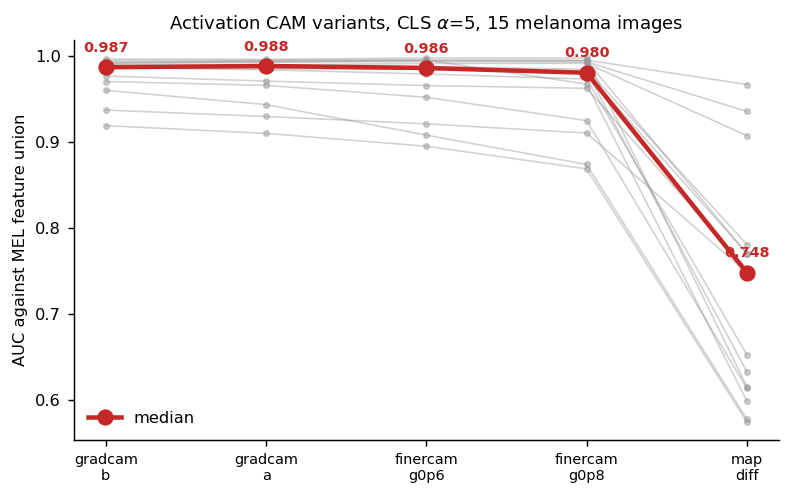

In [6]:
# =============================================================================
# FIGURE 2. Paired slope plot.
#
# EXPECT: near horizontal lines. Every image scores the same under both
#         methods. map_diff sits clearly lower.
# READ:   flat lines are the result. There is nothing for Finer-CAM to add.
# =============================================================================
order = ["gradcam_b", "gradcam_a", "finercam_g0p6", "finercam_g0p8", "map_diff"]
order = [v for v in order if v in e2src.variant.values]
piv = e2src.pivot_table(index="image_id", columns="variant",
                        values="cam_auc")[order].dropna()

fig, ax = plt.subplots(figsize=(7.0, 4.0))
x = np.arange(len(order))
for _, row in piv.iterrows():
    ax.plot(x, row.to_numpy(), "-o", color="#999999", alpha=0.45, ms=3, lw=0.9)

med = piv.median()
ax.plot(x, med.to_numpy(), "-o", color=C_MEL, lw=2.5, ms=8, label="median")
for xi, v in zip(x, med.to_numpy()):
    ax.text(xi, v + 0.018, f"{v:.3f}", ha="center", fontsize=8,
            color=C_MEL, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([o.replace("_", "\n") for o in order], fontsize=8)
ax.set_ylabel("AUC against MEL feature union")
ax.set_title(f"Activation CAM variants, {POOL_TAG.upper()} "
             f"$\\alpha$={AVAL[A_HI]:g}, {len(piv)} melanoma images")
ax.legend(frameon=False)
fig.savefig(FIG / "fig2_E2_paired_slope.png")
plt.show()

In [7]:
# =============================================================================
# E4. Does alignment training collapse class discriminativeness.
#
# The 12c table gave medians only. Recompute per image so the effect
# can carry a confidence interval and a paired test.
# =============================================================================
cams, src_meta = {}, {}
for _, r in man.iterrows():
    if r.family == "activation":
        if r.cam_type != "finercam" and float(r.gamma) != 0.6:
            continue
        src = (f"act_{r.ckpt}_{r.cam_type}_gam{str(r.gamma).replace('.','p')}"
               if r.cam_type == "finercam" else f"act_{r.ckpt}_{r.cam_type}")
    else:
        src = f"attn_{r.ckpt}_{r.cam_type}"
    arr = np.load(REPO / r.path)
    cams[(r.image_id, src)] = (cam_to_grid(arr)
                               if arr.shape != (CAM_GRID, CAM_GRID) else arr)
    src_meta[src] = {"family": "attn" if r.family == "attention" else "act",
                     "ckpt": r.ckpt, "cam_type": r.cam_type}


def topk_fixed(c, k=TOP_K):
    f = np.asarray(c, np.float32).ravel()
    o = np.zeros(f.size, bool)
    o[np.argpartition(-f, k - 1)[:k]] = True
    return o.reshape(c.shape)


rows = []
for fam, a, b in [("act", "gradcam_a", "gradcam_b"),
                  ("attn", "attncam_a", "attncam_b")]:
    for ck in ALPHAS:
        sa, sb = f"{fam}_{ck}_{a}", f"{fam}_{ck}_{b}"
        for img in eval_df.image_id:
            ca, cb = cams.get((img, sa)), cams.get((img, sb))
            if ca is None or cb is None:
                continue
            na, nb = norm01(ca), norm01(cb)
            ma, mb = topk_fixed(na), topk_fixed(nb)
            rows.append({
                "image_id": img, "family": fam, "ckpt": ck,
                "alpha": AVAL[ck],
                "pearson": float(np.corrcoef(na.ravel(), nb.ravel())[0, 1]),
                "topk_iou": float((ma & mb).sum() / ((ma | mb).sum() + 1e-8)),
                "mad": float(np.abs(na - nb).mean()),
            })

disc = pd.DataFrame(rows)
disc = disc.merge(pred[["image_id", "gt_label", "case_type"]], on="image_id")
disc.to_csv(RES / "E4_discriminativeness_per_image.csv", index=False)

print("class discriminativeness, median with bootstrap 95 percent CI\n")
for fam, name in [("attn", "attention-CAM"), ("act", "activation-CAM")]:
    print(name)
    for ck in ALPHAS:
        s = disc[(disc.family == fam) & (disc.ckpt == ck)]
        pm, plo, phi = boot_median_ci(s.pearson)
        im, ilo, ihi = boot_median_ci(s.topk_iou)
        print(f"  {ck}  pearson {pm:+.3f} [{plo:+.3f}, {phi:+.3f}]   "
              f"IoU {im:.3f} [{ilo:.3f}, {ihi:.3f}]   n={len(s)}")
    print()

print("paired tests, pearson similarity between class maps")
for fam, name in [("attn", "attention"), ("act", "activation")]:
    s = disc[disc.family == fam]
    for a, b in [("ha3", "ha0"), ("ha5", "ha0")]:
        r = paired_stats(s, "pearson", "ckpt", a, b)
        print(f"  {name:<11} {a} vs {b}  {fmt(r)}")

class discriminativeness, median with bootstrap 95 percent CI

attention-CAM
  ha0  pearson -0.140 [-0.183, -0.124]   IoU 0.000 [0.000, 0.026]   n=34
  ha3  pearson +0.983 [+0.978, +0.987]   IoU 0.600 [0.481, 0.667]   n=34
  ha5  pearson +0.985 [+0.979, +0.989]   IoU 0.600 [0.538, 0.667]   n=34

activation-CAM
  ha0  pearson -0.490 [-0.539, -0.475]   IoU 0.000 [0.000, 0.000]   n=34
  ha3  pearson +0.995 [+0.993, +0.996]   IoU 0.818 [0.739, 0.905]   n=34
  ha5  pearson +0.995 [+0.994, +0.997]   IoU 0.818 [0.818, 0.905]   n=34

paired tests, pearson similarity between class maps
  attention   ha3 vs ha0  n=34  diff=+1.121 [+1.101, +1.161]  p=0.0000  r=+1.00  (34/0)
  attention   ha5 vs ha0  n=34  diff=+1.121 [+1.103, +1.162]  p=0.0000  r=+1.00  (34/0)
  activation  ha3 vs ha0  n=34  diff=+1.484 [+1.459, +1.511]  p=0.0000  r=+1.00  (34/0)
  activation  ha5 vs ha0  n=34  diff=+1.484 [+1.462, +1.511]  p=0.0000  r=+1.00  (34/0)


best TP_MEL demonstrations:
              ha0    ha3    ha5   gain gt_label case_type
image_id                                                 
ISIC_0028897  0.0  0.905  1.000  1.000      MEL    TP_MEL
ISIC_0024756  0.0  0.818  0.905  0.905      MEL    TP_MEL
ISIC_0025132  0.0  0.818  0.905  0.905      MEL    TP_MEL
ISIC_0031565  0.0  0.905  0.905  0.905      MEL    TP_MEL
ISIC_0032462  0.0  0.818  0.905  0.905      MEL    TP_MEL

using ISIC_0028897


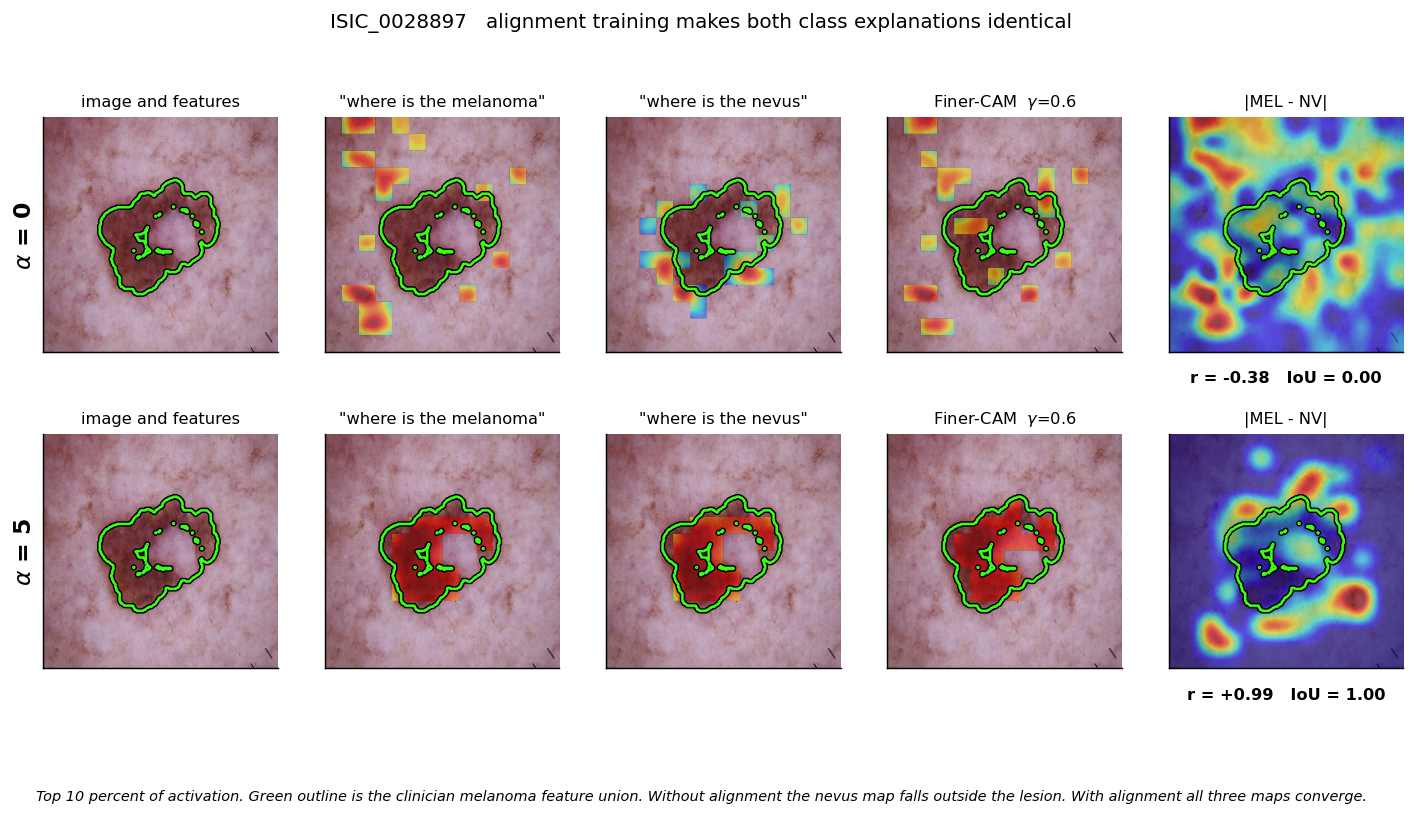

In [8]:
# =============================================================================
# FIGURE 3. The headline.
#
# 2 rows x 5 columns. Activation family so Finer-CAM can be included.
#   image | GradCAM MEL | GradCAM NV | Finer-CAM | absolute difference
#
# EXPECT alpha=0  the two class maps light different regions
# EXPECT alpha=5  maps identical, difference empty
# =============================================================================
FAM       = "act"
# HERO_PICK = "ISIC_0029013"      # set to None to auto select
HERO_PICK = None

sel = (disc[disc.family == FAM]
       .pivot_table(index="image_id", columns="ckpt", values="topk_iou"))
if A_LO in sel and A_HI in sel:
    sel["gain"] = sel[A_HI] - sel[A_LO]
    sel = sel.join(pred.set_index("image_id")[["gt_label", "case_type"]])
    cand = sel[(sel.gt_label == "MEL") &
               (sel.case_type == "TP_MEL")].sort_values("gain", ascending=False)
    print("best TP_MEL demonstrations:")
    print(cand.head(5).round(3).to_string())

HERO = HERO_PICK if (HERO_PICK and (HERO_PICK, f"{FAM}_{A_HI}_gradcam_a") in cams) \
       else cand.index[0]
print(f"\nusing {HERO}")

def cropped_rgb(image_id):
    """Display view under the active GEOMETRY."""
    rel = eval_df.set_index("image_id").loc[image_id, "image_rel_path"]
    img = np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))
    return transform_rgb(img, GEOMETRY)


def mel_union_mask(image_id):
    sub = qcp[(qcp.Image_ID == image_id) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return transform_mask(acc, GEOMETRY)[0]


def overlay(ax, rgb, cam=None, outline=None, title=None, topk=True):
    ax.imshow(rgb)
    if cam is not None:
        c = norm01(cam)
        if topk:
            # threshold at grid resolution, then upsample the selection.
            # thresholding after upsampling would select 20 PIXELS, not
            # 20 patches.
            sel = topk_fixed(c)
            c_up = cv2.resize(c, (rgb.shape[1], rgb.shape[0]),
                              interpolation=cv2.INTER_CUBIC)
            s_up = cv2.resize(sel.astype(np.float32),
                              (rgb.shape[1], rgb.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
            c = np.where(s_up > 0.5, c_up, np.nan)
        else:
            c = cv2.resize(c, (rgb.shape[1], rgb.shape[0]),
                           interpolation=cv2.INTER_CUBIC)
        ax.imshow(c, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    if outline is not None:
        o = outline.astype(float)
        ax.contour(o, [0.5], colors="black", linewidths=3.0)
        ax.contour(o, [0.5], colors="#39FF14", linewidths=1.4)
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)


rgb = cropped_rgb(HERO)
un  = mel_union_mask(HERO)

fig, axes = plt.subplots(2, 5, figsize=(13.5, 5.8))
for row, ck in enumerate([A_LO, A_HI]):
    ca = cams[(HERO, f"{FAM}_{ck}_gradcam_a")]
    cb = cams[(HERO, f"{FAM}_{ck}_gradcam_b")]
    cf = cams.get((HERO, f"{FAM}_{ck}_finercam_gam0p6"))
    d  = np.abs(norm01(ca) - norm01(cb))
    r  = disc[(disc.image_id == HERO) & (disc.family == FAM) &
              (disc.ckpt == ck)].iloc[0]

    overlay(axes[row, 0], rgb, None, un, "image and features")
    overlay(axes[row, 1], rgb, ca, un, '"where is the melanoma"')
    overlay(axes[row, 2], rgb, cb, un, '"where is the nevus"')
    overlay(axes[row, 3], rgb, cf, un, "Finer-CAM  $\\gamma$=0.6")
    overlay(axes[row, 4], rgb, d,  un, "|MEL - NV|", topk=False)

    axes[row, 0].set_ylabel(f"$\\alpha$ = {AVAL[ck]:g}", fontsize=13,
                            fontweight="bold")
    axes[row, 4].text(0.5, -0.13,
                      f"r = {r.pearson:+.2f}   IoU = {r.topk_iou:.2f}",
                      transform=axes[row, 4].transAxes, ha="center",
                      fontsize=9, fontweight="bold")

fig.suptitle(f"{HERO}   alignment training makes both class explanations identical",
             fontsize=11, y=1.00)
fig.text(0.5, -0.045,
         "Top 10 percent of activation. Green outline is the clinician melanoma "
         "feature union. Without alignment the nevus map falls outside the lesion. "
         "With alignment all three maps converge.",
         ha="center", fontsize=8, style="italic")
fig.savefig(FIG / "fig3_E4_discriminativeness_collapse.png")
plt.show()

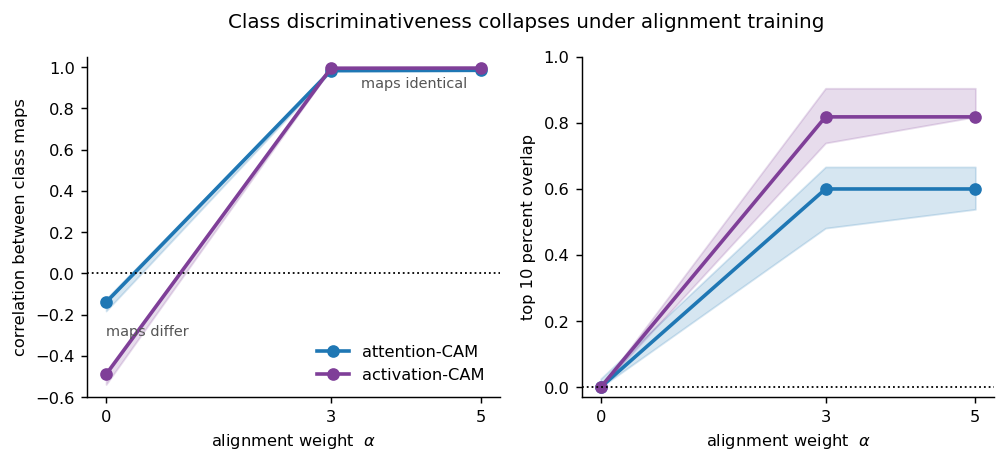

In [9]:
# =============================================================================
# FIGURE 4. Collapse as a function of alpha.
#
# EXPECT: pearson jumps from negative to near 1.0 between alpha 0 and 3.
#         activation collapses harder than attention.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

for ax, metric, ylab, ylim in [
    (axes[0], "pearson",  "correlation between class maps", (-0.6, 1.05)),
    (axes[1], "topk_iou", "top 10 percent overlap",         (-0.03, 1.0)),
]:
    for fam, col, name in [("attn", C_ATTN, "attention-CAM"),
                           ("act", C_ACT, "activation-CAM")]:
        xs, ys, lo, hi = [], [], [], []
        for ck in ALPHAS:
            v = disc[(disc.family == fam) & (disc.ckpt == ck)][metric]
            m, l, h = boot_median_ci(v)
            xs.append(AVAL[ck]); ys.append(m); lo.append(l); hi.append(h)
        ax.plot(xs, ys, "o-", color=col, lw=2, ms=6, label=name)
        ax.fill_between(xs, lo, hi, color=col, alpha=0.18)
    ax.axhline(0, color="k", ls=":", lw=1)
    ax.set_xticks(sorted(AVAL[c] for c in ALPHAS))
    ax.set_xlabel(r"alignment weight  $\alpha$")
    ax.set_ylabel(ylab)
    ax.set_ylim(*ylim)

axes[0].legend(frameon=False, loc="lower right")
axes[0].annotate("maps differ", xy=(0, -0.3), fontsize=8, color="#555555")
axes[0].annotate("maps identical", xy=(3.4, 0.90), fontsize=8, color="#555555")
fig.suptitle("Class discriminativeness collapses under alignment training",
             fontsize=11)
fig.savefig(FIG / "fig4_E4_collapse_curve.png")
plt.show()

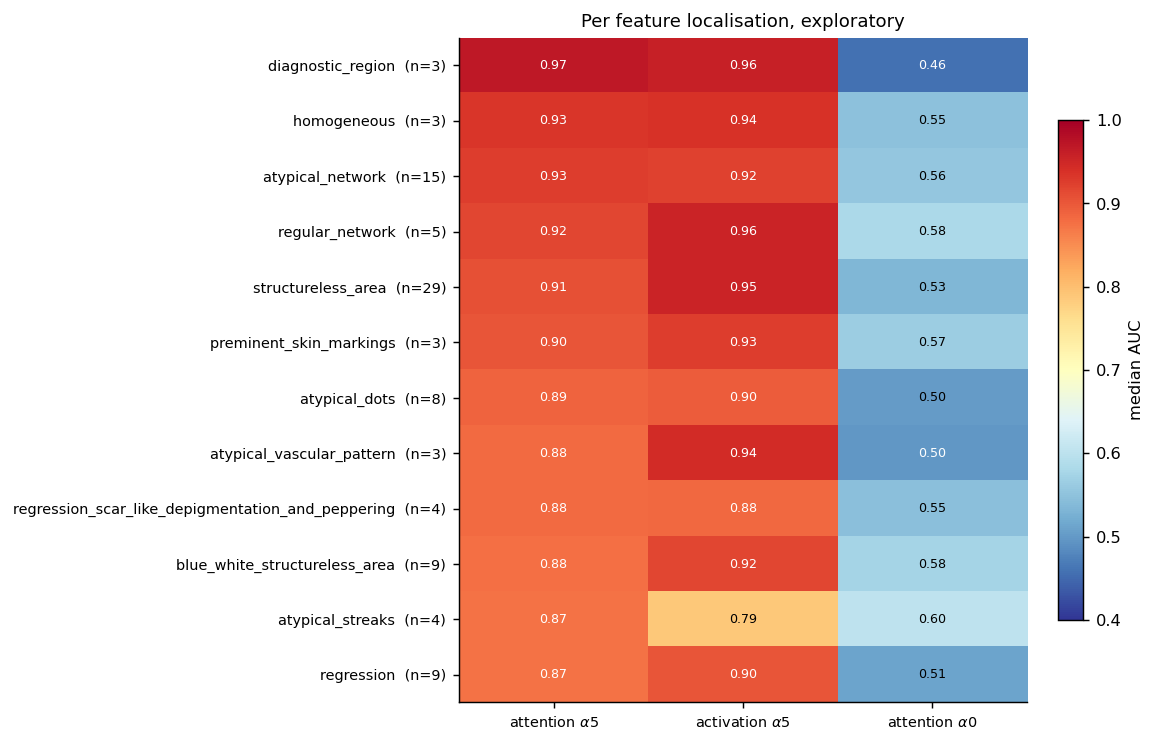

                                                   attention $\alpha$5  activation $\alpha$5  attention $\alpha$0
label                                                                                                            
diagnostic_region                                                0.969                 0.960                0.458
homogeneous                                                      0.932                 0.938                0.550
atypical_network                                                 0.927                 0.922                0.556
regular_network                                                  0.916                 0.955                0.582
structureless_area                                               0.908                 0.953                0.535
preminent_skin_markings                                          0.902                 0.925                0.566
atypical_dots                                                    0.888                 0

In [10]:
# =============================================================================
# E3. Which individual features does the CAM localise.
# EXPLORATORY. Labels overlap spatially so these are not independent.
#
# EXPECT: large diffuse labels score high. small focal labels score low.
# WATCH:  n below 4 is anecdote, not evidence. Shown for completeness only.
# =============================================================================
lab = long_df[long_df.target_kind == "label"].copy()
lab["label"] = lab.target.str.replace("label_", "", regex=False)

counts = lab.groupby("label").image_id.nunique()
keep = counts[counts >= 3].index.tolist()

src_show = [("attn", "attncam_a", "ha5", "attention $\\alpha$5"),
            ("act",  "gradcam_a", "ha5", "activation $\\alpha$5"),
            ("attn", "attncam_a", "ha0", "attention $\\alpha$0")]

mat = {}
for fam, ct, ck, name in src_show:
    s = lab[(lab.family == fam) & (lab.cam_type == ct) & (lab.ckpt == ck)]
    mat[name] = s[s.label.isin(keep)].groupby("label").cam_auc.median()
hm = pd.DataFrame(mat).reindex(
    sorted(keep, key=lambda l: mat[src_show[0][3]].get(l, 0), reverse=True))

fig, ax = plt.subplots(figsize=(6.2, 0.42 * len(hm) + 1.6))
im = ax.imshow(hm.to_numpy(), cmap="RdYlBu_r", vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(hm.shape[1]))
ax.set_xticklabels(hm.columns, fontsize=8)
ax.set_yticks(range(len(hm)))
ax.set_yticklabels([f"{l}  (n={counts[l]})" for l in hm.index], fontsize=8)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.iat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.85 or v < 0.5 else "black")
plt.colorbar(im, ax=ax, label="median AUC", fraction=0.04)
ax.set_title("Per feature localisation, exploratory", fontsize=10)
fig.savefig(FIG / "fig5_E3_per_label.png")
plt.show()

print(hm.round(3).to_string())

In [11]:
# =============================================================================
# EXPLORATORY. Does alignment quality depend on prediction correctness.
#
# UNPAIRED. Each image is either correct or wrong, so Mann-Whitney, not
# Wilcoxon signed rank.
#
# EXPECT no strong pattern if the CAM tracks the decision.
# NOTE   the observed direction is the opposite of that expectation.
# =============================================================================
ct = mel_raw[(mel_raw.family == "attn") &
             (mel_raw.cam_type == "attncam_a") &
             (mel_raw.ckpt == A_HI)]

print(f"attention alpha={AVAL[A_HI]:g}, MEL union AUC by case type:")
print(ct.groupby("case_type").cam_auc.agg(["count", "median", "mean"])
      .round(3).to_string())

print("\ncorrect versus wrong:")
print(ct.groupby("correct").cam_auc.agg(["count", "median", "mean", "std"])
      .round(3).to_string())

a = ct[ct.correct].cam_auc.dropna()
b = ct[~ct.correct].cam_auc.dropna()
if len(a) >= 3 and len(b) >= 3:
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    cliffs = 2 * u / (len(a) * len(b)) - 1
    print(f"\nMann-Whitney U  n={len(a)} vs {len(b)}  p={p:.4f}  "
          f"Cliff's delta={cliffs:+.3f}")
    print(f"  correct {np.median(a):.3f}   wrong {np.median(b):.3f}")
    print("\nIf the CAM explained the decision, quality should be WORSE on")
    print("wrong predictions. Exploratory, unpaired, small n.")

attention alpha=5, MEL union AUC by case type:
           count  median   mean
case_type                      
FN_MEL         3   0.970  0.973
FP_MEL        10   0.977  0.970
TN_NV          6   0.901  0.907
TP_MEL        12   0.957  0.945

correct versus wrong:
         count  median   mean    std
correct                             
False       13   0.970  0.971  0.022
True        18   0.941  0.932  0.048

Mann-Whitney U  n=18 vs 13  p=0.0291  Cliff's delta=-0.470
  correct 0.941   wrong 0.970

If the CAM explained the decision, quality should be WORSE on
wrong predictions. Exploratory, unpaired, small n.


In [12]:
# =============================================================================
# TABLE 1, main. Alignment off versus on. mean +/- std, supervisor convention.
# TABLE 2, ablation. Every alpha.
#
# Median with bootstrap CI and the paired test are kept in E1_statistics.csv
# as supporting detail.
# =============================================================================
def collect(fam, ct_map, ck):
    raw = mel_raw[(mel_raw.family == fam) & (mel_raw.cam_type == ct_map) &
                  (mel_raw.ckpt == ck)]
    con = mel_con[(mel_con.family == fam) & (mel_con.cam_type == ct_map) &
                  (mel_con.ckpt == ck)]
    d = disc[(disc.family == fam) & (disc.ckpt == ck)]
    nl = nullcmp[(nullcmp.target == "union_MEL") &
                 (nullcmp.source == f"{fam}_{ck}_{ct_map}")]

    out = {"n": len(raw)}

    for metric, name in METRICS_RAW:
        if metric == "pointing":
            continue                      # handled below with a count
        out[name] = mean_std(raw[metric]) if metric in raw else "-"

    if "pointing" in raw.columns and len(raw):
        hit = int(raw.pointing.sum())
        out["Pointing game"] = f"{raw.pointing.mean():.3f} ({hit}/{len(raw)})"

    if "dice_max" in raw.columns and len(raw):
        out["Dice ceiling"] = f"{raw.dice_max.mean():.3f}"

    out["AUC in-lesion"]  = mean_std(con.c_auc) if len(con) else "-"
    out["AUC above null"] = (f"{raw.cam_auc.median() - nl.null_auc_mean.iloc[0]:.3f}"
                             if len(nl) else "-")
    out["Class map r"]    = mean_std(d.pearson) if len(d) else "-"
    return out


PRIMARY = ("attn", "attncam_a", "attention-CAM")

t1 = pd.DataFrame({
    f"$\\alpha$ = {AVAL[A_LO]:g}": collect(*PRIMARY[:2], A_LO),
    f"$\\alpha$ = {AVAL[A_HI]:g}": collect(*PRIMARY[:2], A_HI),
})
t1.to_csv(RES / "table1_main.csv")
t1.to_latex(RES / "table1_main.tex", escape=False)
print("=" * 76)
print(f"TABLE 1, MAIN. {PRIMARY[2]}, {POOL_TAG} pooling, {GEOMETRY}, "
      f"MEL feature union")
print("=" * 76)
print(t1.to_string())

rows = []
for fam, ct_map, fname in [("attn", "attncam_a", "attention-CAM"),
                           ("act",  "gradcam_a", "activation-CAM")]:
    for ck in ALPHAS:
        r = collect(fam, ct_map, ck)
        if r["n"] == 0:
            continue
        rows.append({"pooling": POOL_TAG, "formulation": fname,
                     "alpha": AVAL[ck], **r})

t2 = pd.DataFrame(rows).sort_values(["formulation", "alpha"])
t2["geometry"] = GEOMETRY
t2.to_csv(RES / "table2_ablation.csv", index=False)
t2.to_latex(RES / "table2_ablation.tex", escape=False, index=False)
print("\n\n" + "=" * 76)
print(f"TABLE 2, ABLATION. {POOL_TAG} pooling, {GEOMETRY}")
print("=" * 76)
print(t2.to_string(index=False))
print(f"\nwritten to {RES.relative_to(REPO)}")

TABLE 1, MAIN. attention-CAM, cls pooling, squash224, MEL feature union
                      $\alpha$ = 0       $\alpha$ = 5
n                               31                 31
AUC              0.570 $\pm$ 0.137  0.949 $\pm$ 0.043
Dice             0.253 $\pm$ 0.151  0.531 $\pm$ 0.218
Dice / ceiling   0.374 $\pm$ 0.241  0.749 $\pm$ 0.246
IoU              0.154 $\pm$ 0.103  0.392 $\pm$ 0.211
Pointing game        0.419 (13/31)      0.677 (21/31)
Dice ceiling                 0.706              0.706
AUC in-lesion    0.523 $\pm$ 0.128  0.689 $\pm$ 0.193
AUC above null               0.049              0.100
Class map r     -0.140 $\pm$ 0.094  0.979 $\pm$ 0.018


TABLE 2, ABLATION. cls pooling, squash224
pooling    formulation  alpha  n               AUC              Dice    Dice / ceiling               IoU Pointing game Dice ceiling     AUC in-lesion AUC above null        Class map r  geometry
    cls activation-CAM    0.0 31 0.523 $\pm$ 0.227 0.155 $\pm$ 0.173 0.262 $\pm$ 0.303 0.095 $\p

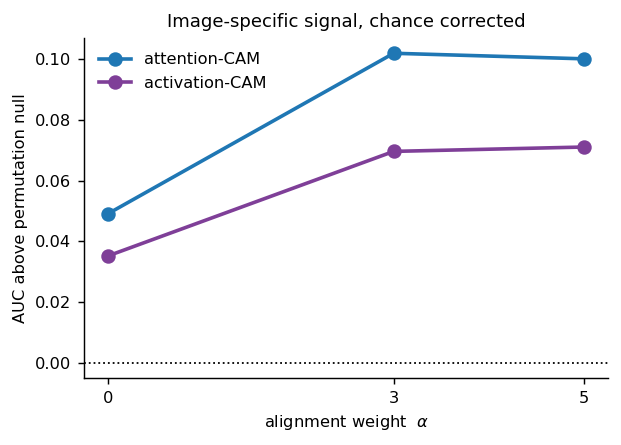

          name  alpha   obs  null  margin
 attention-CAM    0.0 0.571 0.522   0.049
 attention-CAM    3.0 0.959 0.857   0.102
 attention-CAM    5.0 0.963 0.862   0.100
activation-CAM    0.0 0.527 0.492   0.035
activation-CAM    3.0 0.988 0.918   0.070
activation-CAM    5.0 0.989 0.917   0.071


In [13]:
# =============================================================================
# FIGURE 6. Margin over the permutation null.
# EXPECT: attention above activation at alpha 3 and 5, reversing figure 1.
# =============================================================================
rows = []
for fam, ct_, name in [("attn", "attncam_a", "attention-CAM"),
                       ("act",  "gradcam_a", "activation-CAM")]:
    for ck in ALPHAS:
        obs = mel_raw[(mel_raw.family == fam) & (mel_raw.cam_type == ct_) &
                      (mel_raw.ckpt == ck)].cam_auc.median()
        nl = nullcmp[(nullcmp.target == "union_MEL") &
                     (nullcmp.source == f"{fam}_{ck}_{ct_}")]
        rows.append({"name": name, "alpha": AVAL[ck], "obs": obs,
                     "null": float(nl.null_auc_mean.iloc[0]) if len(nl) else np.nan})
m = pd.DataFrame(rows)
m["margin"] = m.obs - m["null"]

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for name, col in [("attention-CAM", C_ATTN), ("activation-CAM", C_ACT)]:
    s = m[m.name == name]
    ax.plot(s.alpha, s.margin, "o-", color=col, lw=2, ms=7, label=name)
ax.axhline(0, color="k", ls=":", lw=1)
ax.set_xticks(sorted(AVAL[c] for c in ALPHAS))
ax.set_xlabel(r"alignment weight  $\alpha$")
ax.set_ylabel("AUC above permutation null")
ax.set_title("Image-specific signal, chance corrected")
ax.legend(frameon=False)
fig.savefig(FIG / "fig6_null_margin.png")
plt.show()
print(m.round(3).to_string(index=False))